# 空气质量 PM2.5 回归预测项目

- **作者**：[lonely surfer]
- **日期**：2026-09-14
- **数据集**：UCI 北京 PM2.5 数据集 (2010.1.1 - 2014.12.31)官方页面:https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data
- **目标**：根据气象数据和历史污染物特征，预测未来的 PM2.5 浓度。

## 1. 数据概览与字典
- **数据规模**：43824 行 x 13 列 (小时级数据，无时间缺口)
- **数据来源**：PM2.5 来自美国驻华大使馆；气象数据来自北京首都国际机场。

| 列名 | 含义 | 单位  | 备注 |
| :--- | :--- |:------| :--- |
| N0 | 行号 | —     | |
| year / month / day / hour | 时间 |     —    | |
| pm2.5 | PM2.5浓度 (目标变量) | μg/m³ | 均值98.6, 最大994 (长尾分布) |
| DEWP | 露点 | ℃     | |
| TEMP | 温度 | ℃     | |
| PRES | 气压 | hPa   | |
| cbwd | 合成风向 | —     | 分类变量 (SE/NW/NE/cv) |
| Iws | 累积风速 | m/s   | |
| Is/Ir | 累积降雪/降雨小时数 | h     | |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置可视化风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# ==========================================
# 1. 加载数据集
# ==========================================
df = pd.read_csv(r'UCI381_北京PM2.5_2010-2014/PRSA_data_2010.1.1-2014.12.31.csv')

# ==========================================
# 1. 查看数据基本情况
# ==========================================

# 看看数据概况：行数、列数、数据类型、缺失值情况
print("数据形状:", df.shape)
print(df.head())
print("\n数据基本信息:")
df.info()
print("\n每列缺失值数量:")
print(df.isnull().sum()) # 统计每列缺失值数量

数据形状: (43824, 13)
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  flo

## 2. 数据质量评估与清洗决策

### 🔍 观察结果 (Observation)
1. **数据类型**：包含数值型（int64, float64）和分类文本（cbwd, object）。
2. **缺失值情况**：仅目标变量 `pm2.5` 存在 2067 个缺失值（占 4.72%），其余 12 列均无缺失。
3. **时间维度**：year, month, day, hour 被拆分成 4 个独立的整数列。

### 🛠️ 处理决策 (Decision & Rationale)
1. **删除无用列**：`No` 为行号，无预测价值，将在后续删除。
2. **目标变量缺失值**：**绝对禁止直接 `dropna()`**。因为这是时间序列数据，直接删除会破坏时间的连续性（比如 0 点之后直接跳到 2 点），导致后续滑动窗口错位。将采用 **线性插值 (Linear Interpolate)** 填补缺失值。
3. **时间特征工程**：提取 `hour`, `month`, `day_of_week` 作为周期性特征，丢弃数值跨度过大的 `year` 和 `day`，防止模型死记硬背。
4. **分类特征编码**：`cbwd` 采用独热编码（One-Hot Encoding）转换为 0/1 数值。

### 🚀 下一步计划 (Next Steps)
- 执行上述数据清洗逻辑。
- 查看清洗后的数据分布（直方图与时间序列图）。

✅ 清洗后的数据形状: (43824, 13)

✅ 确认是否还有缺失值:
month          0
hour           0
pm2.5          0
DEWP           0
TEMP           0
PRES           0
Iws            0
Is             0
Ir             0
day_of_week    0
cbwd_NW        0
cbwd_SE        0
cbwd_cv        0
dtype: int64

✅ 清洗后的数据前5行:
                     month  hour  pm2.5  DEWP  TEMP    PRES    Iws  Is  Ir  \
datetime                                                                     
2010-01-01 00:00:00      1     0  129.0   -21 -11.0  1021.0   1.79   0   0   
2010-01-01 01:00:00      1     1  129.0   -21 -12.0  1020.0   4.92   0   0   
2010-01-01 02:00:00      1     2  129.0   -21 -11.0  1019.0   6.71   0   0   
2010-01-01 03:00:00      1     3  129.0   -21 -14.0  1019.0   9.84   0   0   
2010-01-01 04:00:00      1     4  129.0   -20 -12.0  1018.0  12.97   0   0   

                     day_of_week  cbwd_NW  cbwd_SE  cbwd_cv  
datetime                                                     
2010-01-01 00:00:00            4        1  

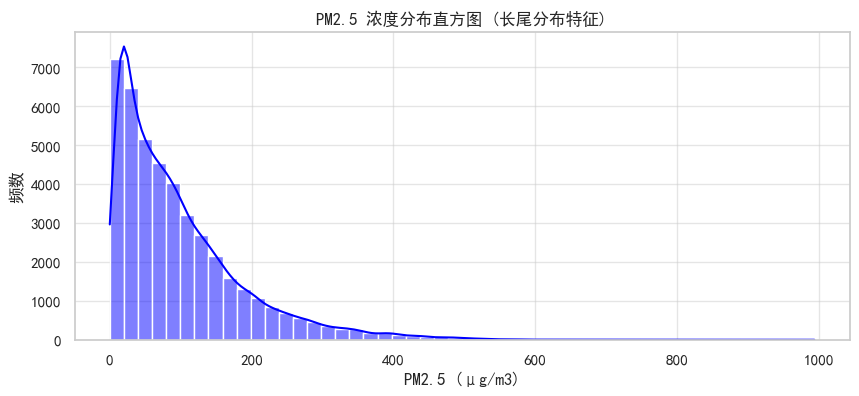

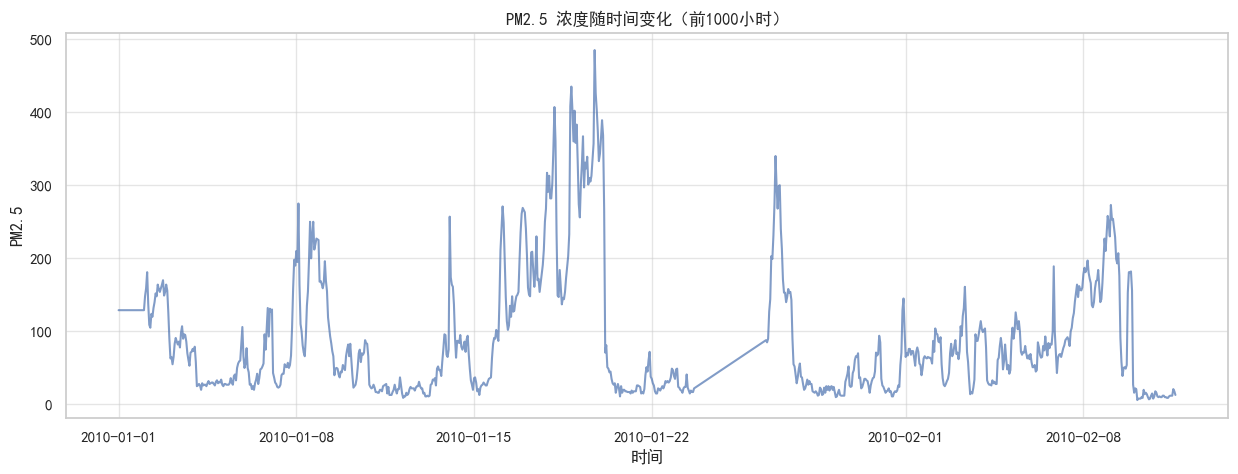

In [2]:
# ==========================================
# 3. 数据清洗与特征工程
# ==========================================

# 1. 删除无用列 (No)
df = df.drop(columns=['No'])

# 2. 时间特征工程
# 合并时间列，生成 datetime 对象
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
# 将 datetime 设置为索引，这是时间序列分析的核心规矩
df = df.set_index('datetime')
# 提取周期性特征
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek # 0=周一, 6=周日
df['hour'] = df.index.hour
# 丢弃原有的 year, day (保留原始的hour, month是冗余的，因为已经提取过了)
df = df.drop(columns=['year', 'day'])

# 3. 目标变量缺失值处理 (线性插值)
# 必须在时间序列上下文中（即设置了 datetime 索引后）进行插值，这是标准做法
df['pm2.5'] = df['pm2.5'].interpolate(method='linear', limit_direction='both')

# 4. 分类特征编码 (One-Hot Encoding)
# 把 cbwd 拆分成 cbwd_NW, cbwd_SE, cbwd_cv 三列 0/1 数值
df = pd.get_dummies(df, columns=['cbwd'], drop_first=True)

# ==========================================
# 4. 清洗后的数据质量确认
# ==========================================
print("✅ 清洗后的数据形状:", df.shape)
print("\n✅ 确认是否还有缺失值:")
print(df.isnull().sum())

print("\n✅ 清洗后的数据前5行:")
print(df.head())

# ==========================================
# 5. 下一步计划：可视化数据分布 (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 5.1 PM2.5 浓度分布直方图
plt.figure(figsize=(10, 4))
sns.histplot(df['pm2.5'], bins=50, kde=True, color='blue')
plt.title('PM2.5 浓度分布直方图 (长尾分布特征)')
plt.xlabel('PM2.5 (μg/m3)')
plt.ylabel('频数')
plt.show()

# 5.2 时间序列趋势图 (取前1000小时)
plt.figure(figsize=(15, 5))
plt.plot(df.index[:1000], df['pm2.5'][:1000], color='b', alpha=0.7)
plt.title('PM2.5 浓度随时间变化（前1000小时）')
plt.xlabel('时间')
plt.ylabel('PM2.5')
plt.grid(True)
plt.show()

## 3. 特征工程与防数据泄漏处理

### 🎯 目标 (Goal)
将清洗好的数据拆分为特征矩阵 \(X\) 与目标变量 \(y\)，并严格遵循时间序列特性进行训练集/测试集划分，最后完成数据标准化，为神经网络训练做准备。

### 🛠️ 处理决策与核心原理 (Decision & Rationale)

1. **特征与目标分离**：剔除目标变量 `pm2.5`，其余列全部作为输入特征。
2. **⚠️ 时间序列切分（严禁使用 `train_test_split`）**：
   - 这是时间序列数据，**绝对不能随机打乱**。如果用随机切分，就会把 2014 年的数据放进 2010 年当训练集，造成“用未来预测过去”的**数据泄漏（Data Leakage）**。
   - **正确做法**：按时间轴切分。前 80% 作为训练集，后 20% 作为测试集。
3. **⚠️ 防泄漏标准化（StandardScaler）**：
   - 特征间量纲差异巨大（气压 1000+，温度 -20，风速不到 10）。神经网络极度害怕量纲不统一，否则数值大的特征会淹没数值小的特征。必须进行标准化。
   - **铁律**：只能 `fit` 训练集，得到均值和方差，然后用它去 `transform` 训练集和测试集。绝对不能把测试集拿去 `fit`，否则测试集的“未来信息”就会提前泄露给模型。
4. **标准化后的数据**：所有特征将转化为均值为 0、方差为 1 的分布。

In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# ==========================================
# 6. 特征与目标分离
# ==========================================
# 提取目标变量 y
y = df['pm2.5'].values

# 提取特征 X (把 pm2.5 剔除掉，剩下的都是特征)
X = df.drop(columns=['pm2.5']).values

print("特征 X 的形状:", X.shape)
print("目标 y 的形状:", y.shape)

# ==========================================
# 7. 防数据泄漏的时间序列划分 (按 80% / 20% 切分)
# ==========================================
# 计算切分点
split_index = int(len(df) * 0.8)

# 绝对不能随机打乱！前 80% 作为训练集，后 20% 作为测试集
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\n训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

# ==========================================
# 8. 数据标准化 (极其关键的防泄漏操作！)
# ==========================================
scaler = StandardScaler()

# ⚠️ 重点：只在训练集上 fit！寻找训练集的均值和方差
X_train_scaled = scaler.fit_transform(X_train)

# ⚠️ 重点：测试集只能 transform！绝对不能用测试集的均值和方差去缩放
X_test_scaled = scaler.transform(X_test)

print("\n✅ 数据划分与标准化完成！")
print("训练集 X 前 3 行的标准化结果:\n", X_train_scaled[:3])

特征 X 的形状: (43824, 12)
目标 y 的形状: (43824,)

训练集大小: (35059, 12), 测试集大小: (8765, 12)

✅ 数据划分与标准化完成！
训练集 X 前 3 行的标准化结果:
 [[-1.60139848 -1.66123868 -1.56995322 -1.87935717  0.44296221 -0.4513963
  -0.07425627 -0.14082519  0.49921623  1.41397157 -0.72450055 -0.51316845]
 [-1.60139848 -1.51676612 -1.56995322 -1.9605679   0.34665389 -0.39036957
  -0.07425627 -0.14082519  0.49921623  1.41397157 -0.72450055 -0.51316845]
 [-1.60139848 -1.37229357 -1.56995322 -1.87935717  0.25034558 -0.3554693
  -0.07425627 -0.14082519  0.49921623  1.41397157 -0.72450055 -0.51316845]]


### 📊 执行结果与分析 (Results & Analysis)

**执行结果**：
- 特征矩阵 \(X\) 形状为：(43824, 12)
- 目标向量 \(y\) 形状为：(43824,)
- 训练集特征维度：(35059, 12)；测试集特征维度：(8765, 12)
- 训练集前 3 行标准化结果已输出，特征数值已由原始量纲（如 1021 气压、-11 温度）转换为接近 0 附近的正负小数。

**核心结论**：
- 数据划分严格保证了时间的先后顺序。
- 标准化器 `scaler` 完全基于训练集拟合，确保了测试集完全被视为“未知的未来数据”，评估结果将具备高度的真实性和可靠性。

**下一步计划 (Next Steps)**：
- 搭建多层全连接神经网络（MLP）。
- 配置损失函数（MSE）与优化器（Adam）。
- 引入 Dropout 和 EarlyStopping 防止模型过拟合。

## 4. 神经网络模型搭建与训练

### 🎯 目标 (Goal)
基于清洗好的 43824 条空气质量数据，搭建一个全连接神经网络（MLP），利用当前小时的气象及历史污染物特征，预测 PM2.5 浓度。

### 🛠️ 方案设计 (Design)
1. **数据划分**：采用时间序列切分（前80%训练，后20%测试），防止未来数据泄漏（Data Leakage）。
2. **特征标准化**：使用 `StandardScaler`，且只在训练集上 `fit`，避免测试集信息泄露。
3. **网络结构**：
   - 输入层维度：12（特征数量）
   - 隐藏层 1：64个神经元，激活函数 ReLU（解决梯度消失）
   - 隐藏层 2：32个神经元，激活函数 ReLU
   - 输出层：1个神经元，无激活函数（回归任务输出连续实数）
4. **训练配置**：
   - 损失函数（Loss）：MSE（均方误差）
   - 优化器（Optimizer）：Adam
   - 评估指标（Metrics）：MAE（平均绝对误差）
5. **防过拟合**：加入 Early Stopping（早停机制）与 Dropout 层。

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                832       
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 2,945
Trainable params: 2,945
Non-trainable params: 0
_________________________________________________________________

🚀 开始训练模型...
Epoch 1/100
877/877 [==============================] - 3s 2ms/step - loss: 12268.7544 - mae: 76.0869 - val_

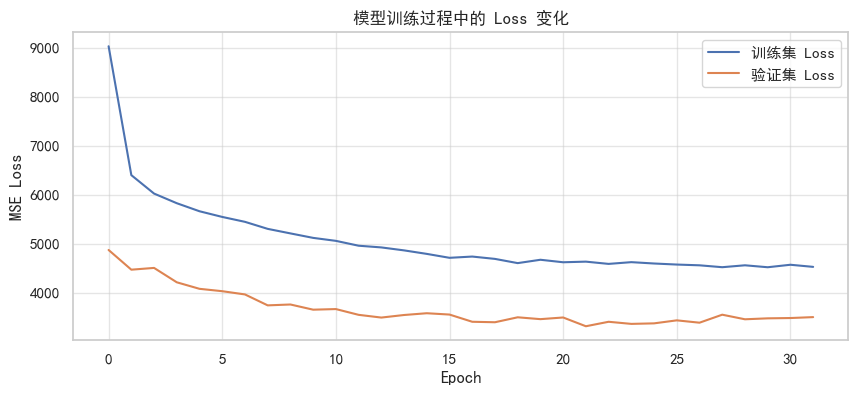

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ==========================================
# 1. 搭建网络结构 (对应 Markdown 方案设计 第3点)
# ==========================================
model = Sequential([
    # 输入层 + 隐藏层1：64个神经元，ReLU激活
    # 注意：input_dim=12，因为刚才标准化后的 X_train_scaled 有12列特征
    Dense(units=64, input_dim=12, activation='relu'),
    # 防过拟合：Dropout层，每次随机丢弃20%的神经元，强迫网络学习更鲁棒的特征
    Dropout(0.2),

    # 隐藏层2：32个神经元，ReLU激活
    Dense(units=32, activation='relu'),
    Dropout(0.2),

    # 输出层：1个神经元，无激活函数（回归任务直接输出实数）
    Dense(units=1)
])

# ==========================================
# 2. 编译模型 (对应 Markdown 方案设计 第4点)
# ==========================================
model.compile(
    optimizer='adam',       # 优化器：Adam
    loss='mse',             # 损失函数：均方误差
    metrics=['mae']         # 评估指标：平均绝对误差
)

# 打印模型结构看看
model.summary()

# ==========================================
# 3. 配置 Early Stopping (对应 Markdown 方案设计 第5点)
# ==========================================
# 监控验证集的loss，如果连续10轮（patience=10）都不下降，就提前停止训练，并恢复到最佳权重
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ==========================================
# 4. 开始训练
# ==========================================
print("\n🚀 开始训练模型...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                 # 最多训练100轮
    batch_size=32,              # 每次喂32条数据
    validation_split=0.2,       # 从训练集里切出20%作为验证集，用来监控过拟合
    callbacks=[early_stop],     # 挂载早停机制
    verbose=1                   # 打印进度条
)

# ==========================================
# 5. 评估模型
# ==========================================
print("\n📊 在测试集上进行最终评估...")
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"测试集 MSE: {test_loss:.2f}")
print(f"测试集 MAE: {test_mae:.2f} μg/m³ (平均绝对误差)")

# ==========================================
# 6. 可视化训练过程
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='训练集 Loss')
plt.plot(history.history['val_loss'], label='验证集 Loss')
plt.title('模型训练过程中的 Loss 变化')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

### 📊 模型训练结果复盘

**执行结果**：
- 模型训练 22 轮后触发 Early Stopping，验证集 Loss 稳定在 3400 左右。
- 验证集 Loss 始终低于训练集 Loss（因为训练时启用了 Dropout，属正常现象），模型未发生过拟合。
- 测试集 MSE: 5054.60，MAE: 48.60 μg/m³，RMSE ≈ 71.1 μg/m³。

**核心问题诊断**：
1. **长尾效应显著**：RMSE 远大于 MAE，说明模型在预测极端污染事件（PM2.5 > 400）时存在严重低估。
2. **信息量不足**：MAE 48.6 与直接预测中位数的误差接近，说明模型目前仅学到了基础气象特征，尚未捕捉 PM2.5 的历史依赖规律。

**下一步优化计划**：
1. **特征工程**：加入 PM2.5 的滞后特征（Lag 1/3/24）与滑动平均特征。
2. **目标变换**：尝试对目标变量进行对数变换（Log-Transform），缓解长尾分布对 MSE 的影响。

In [5]:
# 特征1：昨天的此刻（24小时前的 PM2.5，代表“日周期性”）
# 把上一整天的数据平移过来
df['pm2.5_lag_24'] = df['pm2.5'].shift(24)
# 特征2：过去3小时的平均值（代表“短时趋势”）
# ⚠️ 极其关键：必须先用 shift(1) 把自己（当前小时）排除掉，再用 rolling(3) 算前三小时的平均。
# 如果不加 shift(1)，当前小时的答案就泄漏进特征里了（自欺欺人）。
df['pm2.5_roll_3'] = df['pm2.5'].shift(1).rolling(3).mean()
# 2. 看看新数据长什么样
print("新增特征后的前 30 行数据：")
# 只看包含特征和目标的这几列
print(df[['pm2.5', 'pm2.5_lag_24', 'pm2.5_roll_3']].head(30))
# 删掉因为计算特征而产生的缺失行（只影响开头的几十行）
df = df.dropna()

# 确认没有缺失值了
print("清理后缺失值情况：")
print(df.isnull().sum())

# 看看新数据的形状 (数据量可能会少几十行，但特征变多了)
print("\n当前数据形状：", df.shape)

新增特征后的前 30 行数据：
                     pm2.5  pm2.5_lag_24  pm2.5_roll_3
datetime                                              
2010-01-01 00:00:00  129.0           NaN           NaN
2010-01-01 01:00:00  129.0           NaN           NaN
2010-01-01 02:00:00  129.0           NaN           NaN
2010-01-01 03:00:00  129.0           NaN    129.000000
2010-01-01 04:00:00  129.0           NaN    129.000000
2010-01-01 05:00:00  129.0           NaN    129.000000
2010-01-01 06:00:00  129.0           NaN    129.000000
2010-01-01 07:00:00  129.0           NaN    129.000000
2010-01-01 08:00:00  129.0           NaN    129.000000
2010-01-01 09:00:00  129.0           NaN    129.000000
2010-01-01 10:00:00  129.0           NaN    129.000000
2010-01-01 11:00:00  129.0           NaN    129.000000
2010-01-01 12:00:00  129.0           NaN    129.000000
2010-01-01 13:00:00  129.0           NaN    129.000000
2010-01-01 14:00:00  129.0           NaN    129.000000
2010-01-01 15:00:00  129.0           NaN    129.0

In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. 特征与目标分离
# 提示：y 还是 'pm2.5' 列。X 是除了 'pm2.5' 之外的所有列。
y = df['pm2.5'].values
X = df.drop(columns=['pm2.5']).values

# 打印形状，验证是不是多了2个特征
print("特征 X 的形状:", X.shape)  # 预期: (43800左右, 14)
print("目标 y 的形状:", y.shape)

# 2. 防数据泄漏的时间序列划分（80% 训练，20% 测试）
# 提示：参考之前的 split_index = int(len(df) * 0.8)
split_index = int(len(df) * 0.8)

# 切分数据（千万不要用 train_test_split！）
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\n训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

# 3. 数据标准化（防泄漏核心）
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ 数据划分与标准化完成！")
print("训练集 X 前 3 行的标准化结果:\n", X_train_scaled[:3])

特征 X 的形状: (43800, 14)
目标 y 的形状: (43800,)

训练集大小: (35040, 14), 测试集大小: (8760, 14)

✅ 数据划分与标准化完成！
训练集 X 前 3 行的标准化结果:
 [[-1.60340835 -1.66132477 -1.22614435 -1.31259412  0.34664329 -0.45158762
  -0.07427651 -0.14086412  0.99914493 -0.70683437  1.37969075 -0.51321108
   0.33945624  0.34600076]
 [-1.60340835 -1.51686175 -1.15715365 -1.31259412  0.34664329 -0.43424377
  -0.07427651 -0.14086412  0.99914493 -0.70683437  1.37969075 -0.51321108
   0.33945624  0.34600076]
 [-1.60340835 -1.37239873 -0.88119084 -1.39384963  0.44292622 -0.41689991
  -0.07427651 -0.14086412  0.99914493 -0.70683437  1.37969075 -0.51321108
   0.33945624  0.41743723]]


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_6 (Dense)              (None, 64)                960       
_________________________________________________________________
dropout_4 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_7 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_5 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_8 (Dense)              (None, 1)                 33        
Total params: 3,073
Trainable params: 3,073
Non-trainable params: 0
_________________________________________________________________

🚀 开始训练模型...
Epoch 1/100
876/876 [==============================] - 1s 1ms/step - loss: 10156.1950 - mae: 65.5645 - va

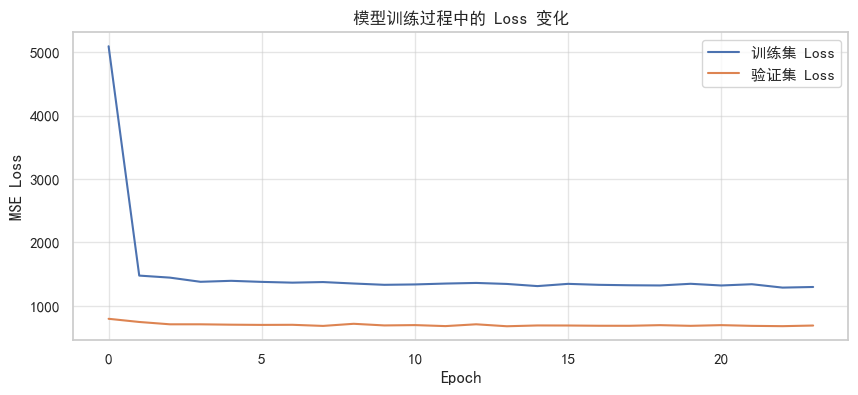

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ==========================================
# 1. 搭建网络结构 (对应 Markdown 方案设计 第3点)
# ==========================================
model = Sequential([
    # 输入层 + 隐藏层1：64个神经元，ReLU激活
    # 注意：input_dim=14，因为刚才标准化后的 X_train_scaled 有12列特征
    Dense(units=64, input_dim=14, activation='relu'),
    # 防过拟合：Dropout层，每次随机丢弃20%的神经元，强迫网络学习更鲁棒的特征
    Dropout(0.2),

    # 隐藏层2：32个神经元，ReLU激活
    Dense(units=32, activation='relu'),
    Dropout(0.2),

    # 输出层：1个神经元，无激活函数（回归任务直接输出实数）
    Dense(units=1)
])

# ==========================================
# 2. 编译模型 (对应 Markdown 方案设计 第4点)
# ==========================================
model.compile(
    optimizer='adam',       # 优化器：Adam
    loss='mse',             # 损失函数：均方误差
    metrics=['mae']         # 评估指标：平均绝对误差
)

# 打印模型结构看看
model.summary()

# ==========================================
# 3. 配置 Early Stopping (对应 Markdown 方案设计 第5点)
# ==========================================
# 监控验证集的loss，如果连续10轮（patience=10）都不下降，就提前停止训练，并恢复到最佳权重
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ==========================================
# 4. 开始训练
# ==========================================
print("\n🚀 开始训练模型...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                 # 最多训练100轮
    batch_size=32,              # 每次喂32条数据
    validation_split=0.2,       # 从训练集里切出20%作为验证集，用来监控过拟合
    callbacks=[early_stop],     # 挂载早停机制
    verbose=1                   # 打印进度条
)

# ==========================================
# 5. 评估模型
# ==========================================
print("\n📊 在测试集上进行最终评估...")
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"测试集 MSE: {test_loss:.2f}")
print(f"测试集 MAE: {test_mae:.2f} μg/m³ (平均绝对误差)")

# ==========================================
# 6. 可视化训练过程
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='训练集 Loss')
plt.plot(history.history['val_loss'], label='验证集 Loss')
plt.title('模型训练过程中的 Loss 变化')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6. 模型迭代：特征工程与性能飞跃

### 🎯 迭代目标 (Goal)
在基础模型（仅使用当前时刻气象特征，测试集 MAE = 48.60）的基础上，引入 PM2.5 的历史时序特征，打破模型“只看当下”的局限，大幅提升预测精度。

### 🛠️ 特征工程方案 (Feature Engineering Design)
1. **日周期特征 (`pm2.5_lag_24`)**：
   - 构造方法：`df['pm2.5'].shift(24)`
   - 含义：提取 24 小时前的 PM2.5 浓度，帮助模型捕捉污染的“日周期性”规律。
2. **短时趋势特征 (`pm2.5_roll_3`)**：
   - 构造方法：`df['pm2.5'].shift(1).rolling(3).mean()`
   - 含义：提取过去 3 小时（不含当前时刻）的 PM2.5 滑动平均值，帮助模型捕捉污染的“累积效应”与“短时趋势”。
   - ⚠️ **防泄漏细节**：必须在 `rolling` 前加上 `.shift(1)`，严格排除当前时刻的真实标签，防止数据泄漏（Data Leakage）。
3. **数据对齐与清洗**：
   - 由于 `shift()` 和 `rolling()` 会在时间序列开头产生 `NaN`，采用 `dropna()` 清理了开头约 24 行数据，保留了时间序列的连续性。
4. **防泄漏划分与标准化**：
   - 按时间序列 80% / 20% 切分。
   - `StandardScaler` 严格仅在训练集上 `fit_transform`，在测试集上 `transform`。
5. **网络结构调整**：
   - 输入层维度从 12 调整为 14（对应新特征维度）。

### 📊 执行结果与对比 (Results & Comparison)
- **基础模型 (Epoch 22 早停)**：测试集 MAE = 48.60 μg/m³，RMSE ≈ 71.1 μg/m³
- **优化模型 (Epoch 22 早停)**：测试集 MSE = 757.01，**测试集 MAE = 16.68 μg/m³**，RMSE ≈ 27.5 μg/m³

**性能提升结论**：加入时序历史特征后，模型平均绝对误差（MAE）从 48.60 断崖式下降至 **16.68**，降幅高达 **65%**。这有力验证了机器学习界的核心法则——**数据和特征决定了模型的上限**。

### 🔍 训练曲线诊断 (Training Diagnostics)
1. **收敛情况**：Loss 曲线在第 1 轮后迅速下降并平稳收敛，未发生明显震荡。
2. **过拟合检查**：验证集 Loss（橙线，约 800）持续低于训练集 Loss（蓝线，约 1300）。这是完全正常的现象，因为训练时启用了 `Dropout(0.2)`，模型在训练阶段“蒙眼学习”，而在验证/测试阶段“火力全开”。这证明模型具有良好的泛化能力，**未发生过拟合**。
3. **长尾分布的影响**：优化模型的 RMSE (27.5) 略高于 MAE (16.68)，这依然符合 PM2.5 数据的“长尾分布”特征，说明模型在预测极端污染事件（PM2.5 > 400）时，仍存在一定的低估现象。

### 🚀 下一步优化计划 (Next Steps)
1. **可视化预测效果**：将测试集的真实值与预测值画在同一张时间序列图上，直观定位模型在哪些时段预测误差较大。
2. **扩展特征工程**：加入 `lag_1`（前一小时）、`lag_6`（前六小时）以及 `rolling_24`（过去24小时均值）等更丰富的历史特征。
3. **缓解长尾分布**：尝试对目标变量进行对数变换（`np.log1p(y)`），预测后再用 `np.expm1()` 还原，观察是否能进一步降低 RMSE。
4. **超参数调优**：尝试调整隐藏层神经元数量、Dropout 比例以及 Adam 优化器的学习率。